# Losses training

In [6]:
df = pd.read_csv('losses1.csv')
df.head()
df['avg'] = df[]

,Step,10epcv3lil_ResNet_fold5 - Training loss,10epcv3lil_ResNet_fold5 - Training loss__MIN,10epcv3lil_ResNet_fold5 - Training loss__MAX,10epcv3lil_ResNet_fold4 - Training loss,10epcv3lil_ResNet_fold4 - Training loss__MIN,10epcv3lil_ResNet_fold4 - Training loss__MAX,10epcv3lil_ResNet_fold3 - Training loss,10epcv3lil_ResNet_fold3 - Training loss__MIN,10epcv3lil_ResNet_fold3 - Training loss__MAX,10epcv3lil_ResNet_fold2 - Training loss,10epcv3lil_ResNet_fold2 - Training loss__MIN,10epcv3lil_ResNet_fold2 - Training loss__MAX,10epcv3lil_ResNet_fold1 - Training loss,10epcv3lil_ResNet_fold1 - Training loss__MIN,10epcv3lil_ResNet_fold1 - Training loss__MAX
0,0,0.635879,0.635879,0.635879,0.601423,0.601423,0.601423,0.674021,0.674021,0.674021,0.683106,0.683106,0.683106,0.704712,0.704712,0.704712
1,1,0.491184,0.491184,0.491184,0.471029,0.471029,0.471029,0.501432,0.501432,0.501432,0.515190,0.515190,0.515190,0.533748,0.533748,0.533748
2,2,0.457197,0.457197,0.457197,0.439180,0.439180,0.439180,0.464080,0.464080,0.464080,0.474786,0.474786,0.474786,0.498127,0.498127,0.498127
3,3,0.446269,0.446269,0.446269,0.429955,0.429955,0.429955,0.453373,0.453373,0.453373,0.463614,0.463614,0.463614,0.487325,0.487325,0.487325
4,4,0.442993,0.442993,0.442993,0.427370,0.427370,0.427370,0.450077,0.450077,0.450077,0.460037,0.460037,0.460037,0.484141,0.484141,0.484141


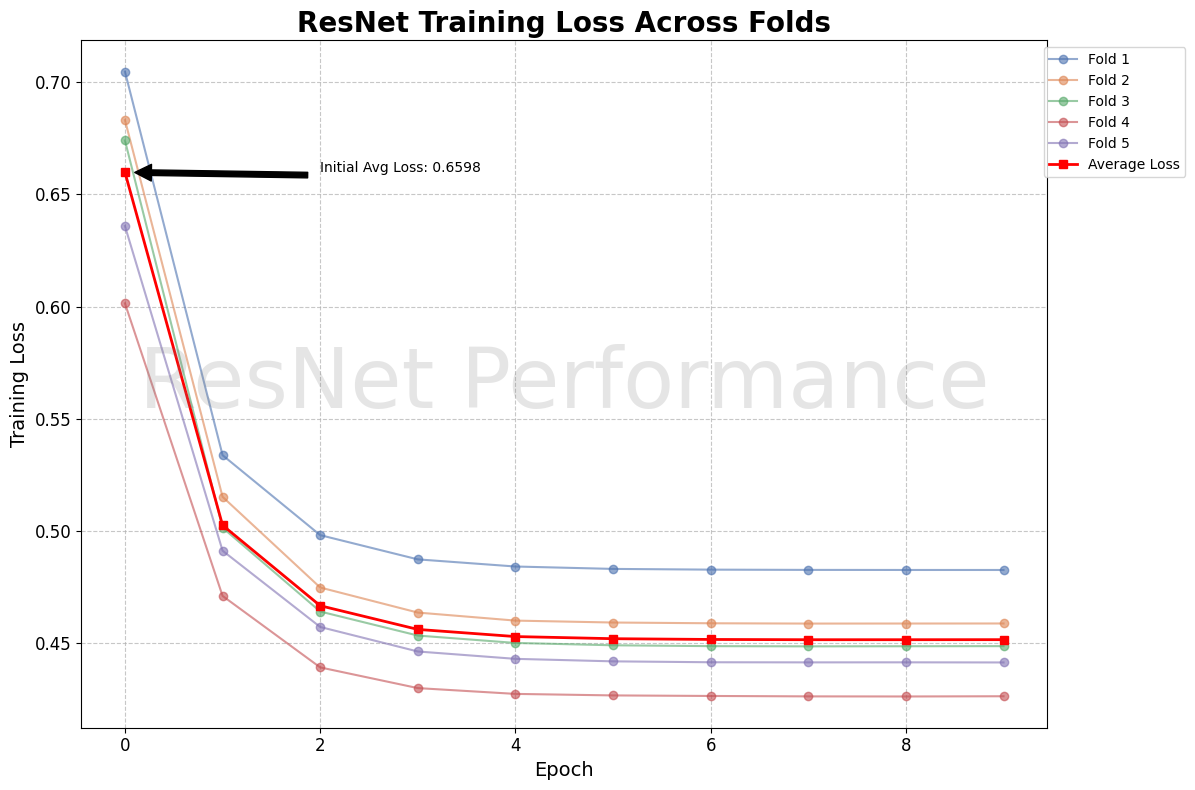

   Step  Average Loss  10epcv3lil_ResNet_fold5 - Training loss  \
0     0      0.659828                                 0.635879   
1     1      0.502517                                 0.491184   
2     2      0.466674                                 0.457197   
3     3      0.456107                                 0.446269   
4     4      0.452924                                 0.442993   
5     5      0.451972                                 0.441877   
6     6      0.451635                                 0.441474   
7     7      0.451518                                 0.441420   
8     8      0.451521                                 0.441441   
9     9      0.451543                                 0.441386   

   10epcv3lil_ResNet_fold4 - Training loss  \
0                                 0.601423   
1                                 0.471029   
2                                 0.439180   
3                                 0.429955   
4                                 0.427370 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Read the CSV data
df = pd.read_csv('losses1.csv')

# Calculate the average loss across all folds for each epoch
loss_columns = [col for col in df.columns if 'Training loss' in col and '__MIN' not in col and '__MAX' not in col]
df['Average Loss'] = df[loss_columns].mean(axis=1)

# Set up the plot style
# plt.style.use('seaborn-darkgrid')
sns.set_palette("deep")
plt.figure(figsize=(12, 8))

# Plot the training loss for each fold and the average
for fold in range(1, 6):
    column_name = f'10epcv3lil_ResNet_fold{fold} - Training loss'
    plt.plot(df['Step'], df[column_name], marker='o', alpha=0.6, label=f'Fold {fold}')

# Plot the average loss
plt.plot(df['Step'], df['Average Loss'], marker='s', color='red', linewidth=2, label='Average Loss')

# Customize the plot
plt.title('ResNet Training Loss Across Folds', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)
plt.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.7)

# Customize tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add annotations for key points
min_avg_loss = df['Average Loss'].min()
max_avg_loss = df['Average Loss'].max()
# plt.annotate(f'Min Avg Loss: {min_avg_loss:.4f}', xy=(df['Average Loss'].idxmin(), min_avg_loss), 
#              xytext=(5, min_avg_loss+0.05), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate(f'Initial Avg Loss: {max_avg_loss:.4f}', xy=(0, max_avg_loss), xytext=(2, max_avg_loss),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

# Add a watermark
plt.text(0.5, 0.5, 'ResNet Performance', fontsize=60, color='gray', 
         ha='center', va='center', alpha=0.2, transform=plt.gca().transAxes)

# Adjust layout and save
plt.tight_layout()
plt.savefig('resnet_training_loss_with_average.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the dataframe with the new average column
print(df[['Step', 'Average Loss'] + loss_columns])

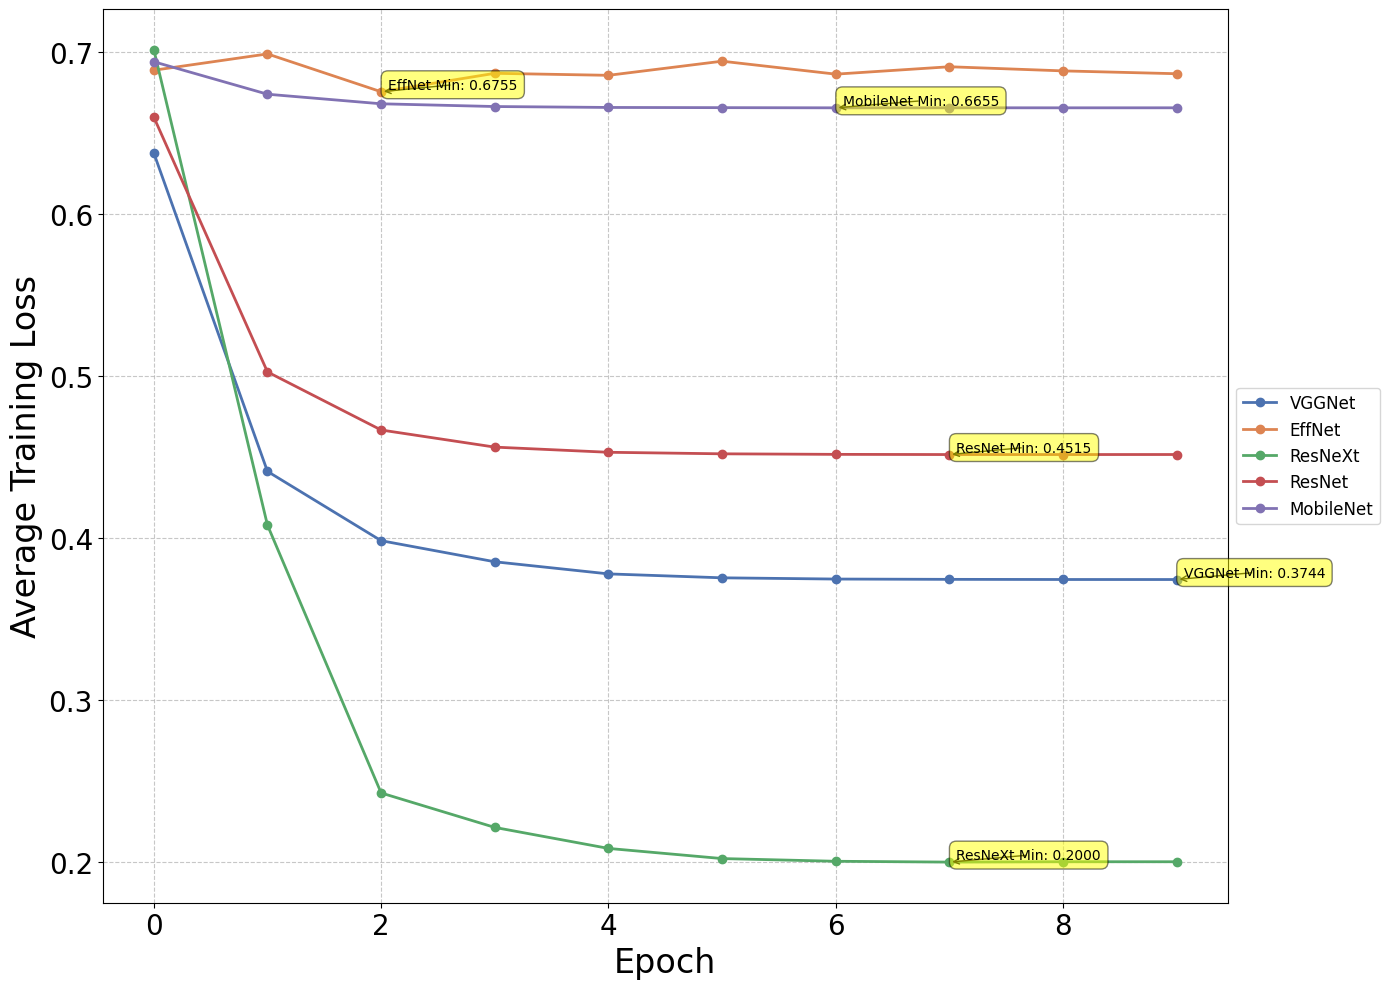

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def load_and_process_csv(file_path):
    df = pd.read_csv(file_path)
    models = set([col.split('_fold')[0] for col in df.columns if 'Training loss' in col and '__MIN' not in col and '__MAX' not in col])
    averages = {}
    for model in models:
        model_columns = [col for col in df.columns if model in col and 'Training loss' in col and '__MIN' not in col and '__MAX' not in col]
        averages[model] = df[model_columns].mean(axis=1)
    return averages

# Load and process each CSV file
csv_files = ['losses_lil_vgg_eff.csv', 'losses_lil_next.csv', 'losses_lil_resmob.csv']
all_averages = {}

for file in csv_files:
    all_averages.update(load_and_process_csv(file))

# Set up the plot
plt.figure(figsize=(14, 10))
# plt.style.use('seaborn-darkgrid')
sns.set_palette("deep")

# Plot the average loss for each model
avg_loss_lil = []
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    plt.plot(range(len(avg_loss)), avg_loss, marker='o', linewidth=2, label=model_name)
    avg_loss_lil.append(avg_loss)

# Customize the plot
# plt.title('Average Training Loss Across Models', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Average Training Loss', fontsize=24)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

# Customize tick labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add annotations for key points
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    min_loss = min(avg_loss)
    plt.annotate(f'{model_name} Min: {min_loss:.4f}', 
                 xy=(avg_loss.idxmin(), min_loss),
                 xytext=(5, 0), textcoords='offset points', ha='left', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# Add a watermark
# plt.text(0.5, 0.5, 'Model Comparison', fontsize=60, color='gray', 
#          ha='center', va='center', alpha=0.2, transform=plt.gca().transAxes)

# Adjust layout and save
plt.tight_layout()
plt.savefig('model_comparison_average_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# # Print the average loss for each model
# for model, avg_loss in all_averages.items():
#     model_name = model.split('_')[-1]
#     print(f"\nAverage loss for {model_name}:")
#     print(avg_loss)

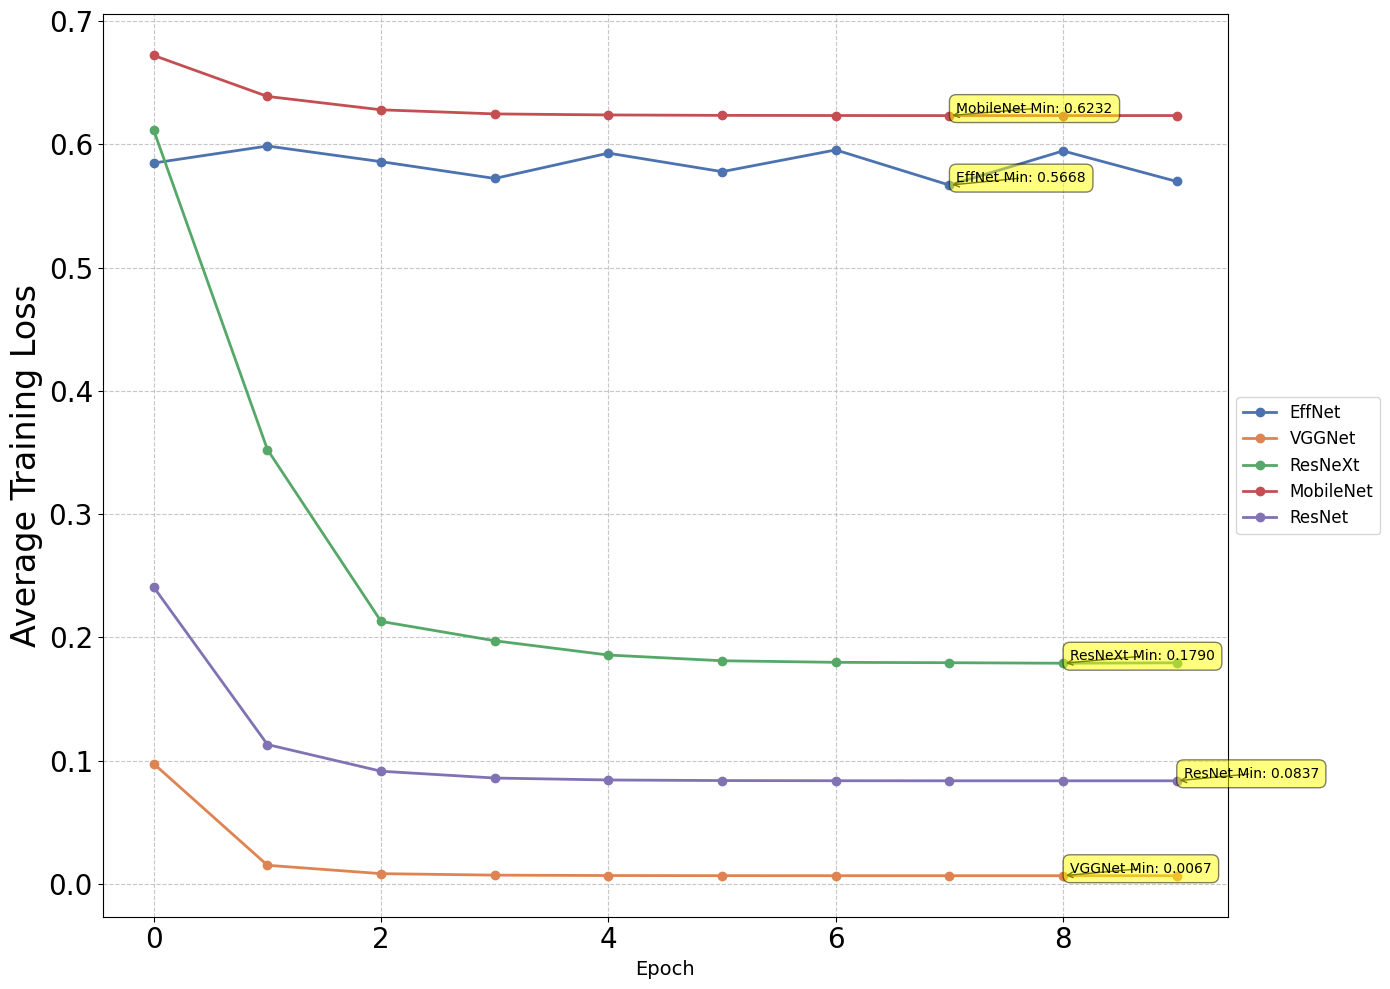

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def load_and_process_csv(file_path):
    df = pd.read_csv(file_path)
    models = set([col.split('_fold')[0] for col in df.columns if 'Training loss' in col and '__MIN' not in col and '__MAX' not in col])
    averages = {}
    for model in models:
        model_columns = [col for col in df.columns if model in col and 'Training loss' in col and '__MIN' not in col and '__MAX' not in col]
        averages[model] = df[model_columns].mean(axis=1)
    return averages

# Load and process each CSV file
csv_files = ['losses_big_vgg_eff.csv', 'losses_big_next.csv', 'losses_big_resmob.csv']
all_averages = {}

for file in csv_files:
    all_averages.update(load_and_process_csv(file))

# Set up the plot
plt.figure(figsize=(14, 10))
# plt.style.use('seaborn-darkgrid')
sns.set_palette("deep")

# Plot the average loss for each model
avg_loss_big = []
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    plt.plot(range(len(avg_loss)), avg_loss, marker='o', linewidth=2, label=model_name)
    avg_loss_big.append(avg_loss) 

# Customize the plot
# plt.title('Average Training Loss Across Models', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average Training Loss', fontsize=24)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

# Customize tick labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add annotations for key points
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    min_loss = min(avg_loss)
    plt.annotate(f'{model_name} Min: {min_loss:.4f}', 
                 xy=(avg_loss.idxmin(), min_loss),
                 xytext=(5, 0), textcoords='offset points', ha='left', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# Add a watermark
# plt.text(0.5, 0.5, 'Model Comparison', fontsize=60, color='gray', 
#          ha='center', va='center', alpha=0.2, transform=plt.gca().transAxes)

# Adjust layout and save
plt.tight_layout()
plt.savefig('model_comparison_average_loss_big.png', dpi=300, bbox_inches='tight')
plt.show()

# # Print the average loss for each model
# for model, avg_loss in all_averages.items():
#     model_name = model.split('_')[-1]
#     print(f"\nAverage loss for {model_name}:")
#     print(avg_loss)

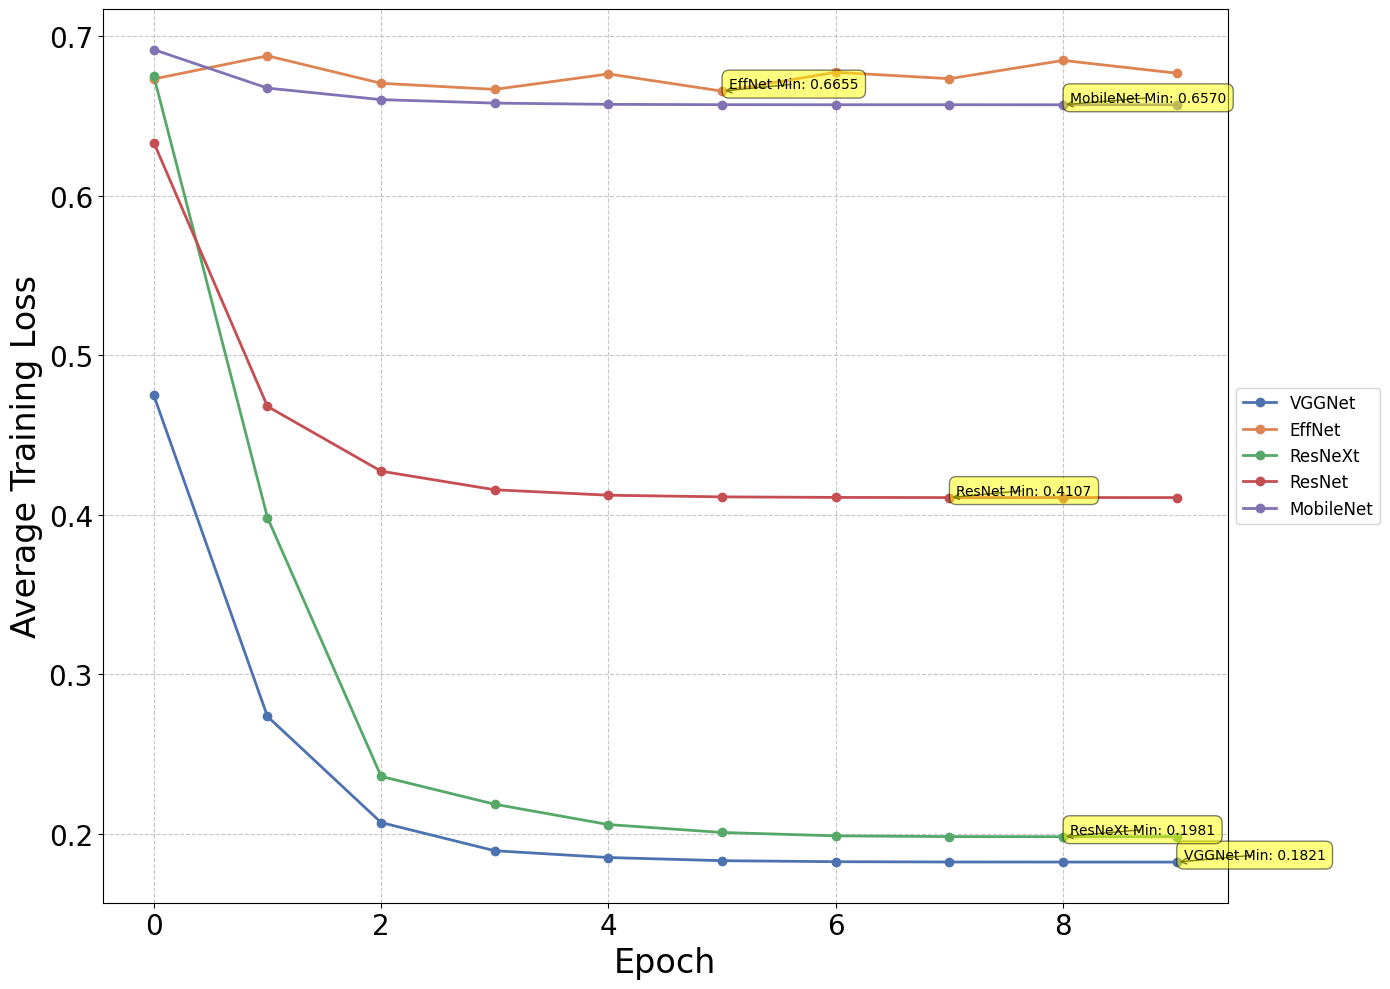

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def load_and_process_csv(file_path):
    df = pd.read_csv(file_path)
    models = set([col.split('_fold')[0] for col in df.columns if 'Training loss' in col and '__MIN' not in col and '__MAX' not in col])
    averages = {}
    for model in models:
        model_columns = [col for col in df.columns if model in col and 'Training loss' in col and '__MIN' not in col and '__MAX' not in col]
        averages[model] = df[model_columns].mean(axis=1)
    return averages

# Load and process each CSV file
csv_files = ['losses_mid_vgg_eff.csv', 'losses_mid_next.csv', 'losses_mid_resmob.csv']
all_averages = {}

for file in csv_files:
    all_averages.update(load_and_process_csv(file))

# Set up the plot
plt.figure(figsize=(14, 10))
# plt.style.use('seaborn-darkgrid')
sns.set_palette("deep")

# Plot the average loss for each model
avg_loss_mid = []
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    plt.plot(range(len(avg_loss)), avg_loss, marker='o', linewidth=2, label=model_name)
    avg_loss_mid.append(avg_loss)

# Customize the plot
# plt.title('Average Training Loss Across Models', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Average Training Loss', fontsize=24)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

# Customize tick labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add annotations for key points
for model, avg_loss in all_averages.items():
    model_name = model.split('_')[-1]
    min_loss = min(avg_loss)
    plt.annotate(f'{model_name} Min: {min_loss:.4f}', 
                 xy=(avg_loss.idxmin(), min_loss),
                 xytext=(5, 0), textcoords='offset points', ha='left', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# Add a watermark
# plt.text(0.5, 0.5, 'Model Comparison', fontsize=60, color='gray', 
#          ha='center', va='center', alpha=0.2, transform=plt.gca().transAxes)

# Adjust layout and save
plt.tight_layout()
plt.savefig('model_comparison_average_loss_mid.png', dpi=300, bbox_inches='tight')
plt.show()

# # Print the average loss for each model
# for model, avg_loss in all_averages.items():
#     model_name = model.split('_')[-1]
#     print(f"\nAverage loss for {model_name}:")
#     print(avg_loss)

In [29]:
np.array(avg_loss_lil).mean(axis=0)

array([0.67633628, 0.5448721 , 0.49023074, 0.48320053, 0.47811151,
       0.4779022 , 0.47572802, 0.47648608, 0.47599778, 0.47564819])

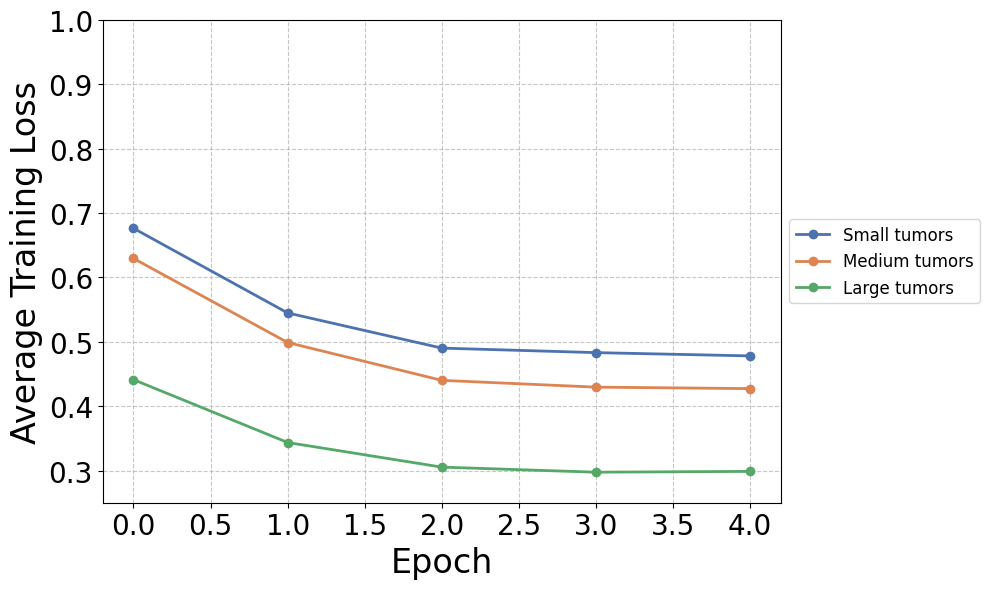

In [30]:
# Set up the plot
plt.figure(figsize=(10, 6))
# plt.style.use('seaborn-darkgrid')
sns.set_palette("deep")

# Plot the average loss for each model
avg_lil, avg_mid, avg_big = np.array(avg_loss_lil).mean(axis=0), np.array(avg_loss_mid).mean(axis=0), np.array(avg_loss_big).mean(axis=0)

plt.plot(range(len(avg_lil[:5])), avg_lil[:5], marker='o', linewidth=2, label="Small tumors")
plt.plot(range(len(avg_lil[:5])), avg_mid[:5], marker='o', linewidth=2, label="Medium tumors")
plt.plot(range(len(avg_lil[:5])), avg_big[:5], marker='o', linewidth=2, label="Large tumors")

# plt.title('Average Training Loss Across Models', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Average Training Loss', fontsize=24)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([0.25, 1])

plt.tight_layout()
# plt.savefig('model_comparison_average_loss_mid.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
mean_lil, std_lil

(array([0.67633628, 0.5448721 , 0.49023074, 0.48320053, 0.47811151,
        0.4779022 , 0.47572802, 0.47648608, 0.47599778, 0.47564819]),
 array([0.02393954, 0.11971791, 0.16506434, 0.17543659, 0.17983703,
        0.18401904, 0.18272906, 0.18397187, 0.18331593, 0.18291724]))

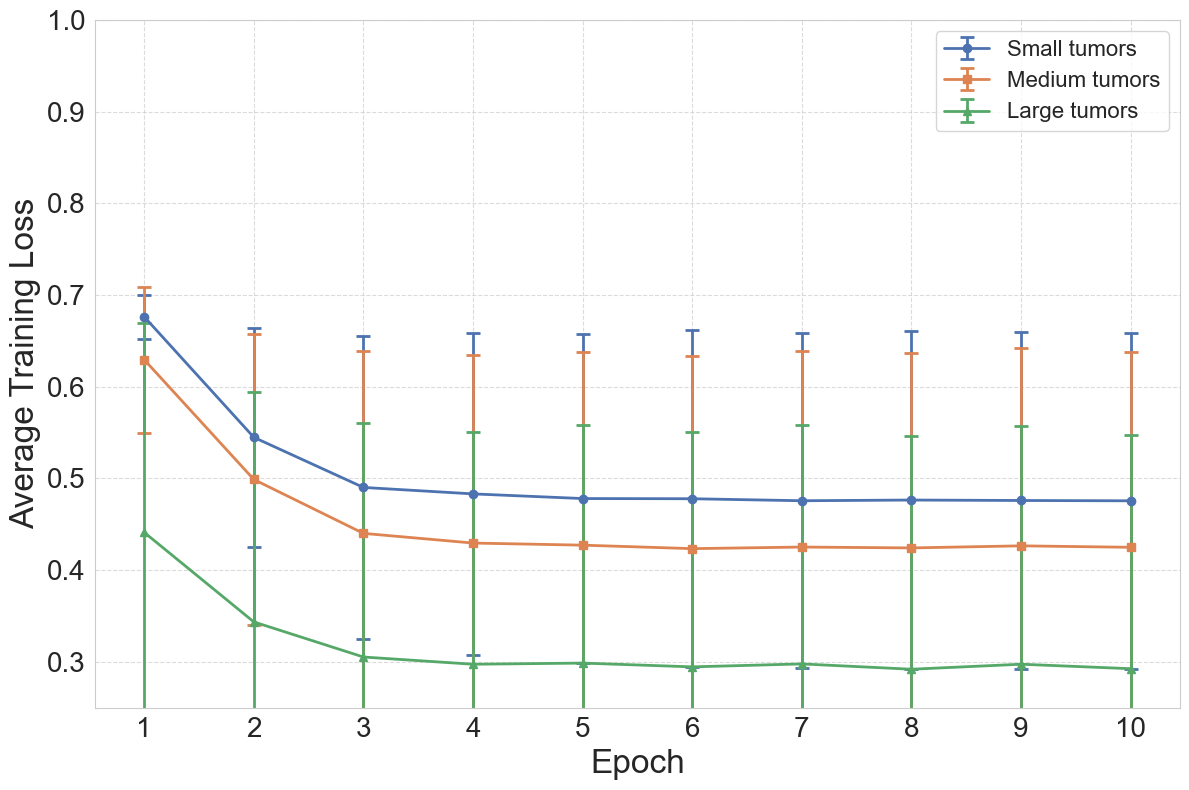

In [37]:
mean_lil, std_lil = np.mean(avg_loss_lil, axis=0), np.std(avg_loss_lil, axis=0)
mean_mid, std_mid = np.mean(avg_loss_mid, axis=0), np.std(avg_loss_mid, axis=0)
mean_big, std_big = np.mean(avg_loss_big, axis=0), np.std(avg_loss_big, axis=0)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.set_palette("deep")

epochs = range(1, 11)
plt.errorbar(epochs, mean_lil, yerr=std_lil, fmt='-o', capsize=5, capthick=2, linewidth=2, label="Small tumors")
plt.errorbar(epochs, mean_mid, yerr=std_mid, fmt='-s', capsize=5, capthick=2, linewidth=2, label="Medium tumors")
plt.errorbar(epochs, mean_big, yerr=std_big, fmt='-^', capsize=5, capthick=2, linewidth=2, label="Large tumors")

plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Average Training Loss', fontsize=24)
plt.legend(fontsize=16, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(epochs, fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([0.25, 1])

plt.tight_layout()
plt.show()

# CONFUSION MATRICES


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('cm.csv')

# Create confusion matrix
cm = df.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
cm

Predicted,0,1
Actual,,
0,133,15
1,28,140


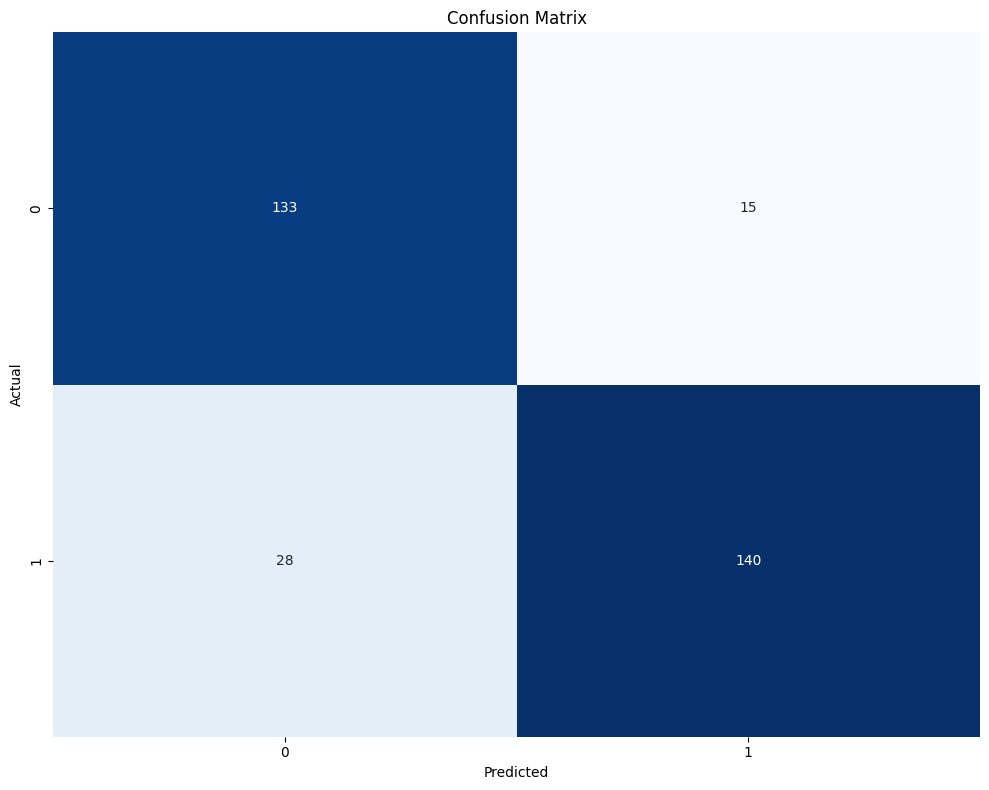

Accuracy: 0.8639
Precision: 0.9032
Recall: 0.8333
F1 Score: 0.8669


In [50]:
# Calculate metrics
tn, fp, fn, tp = cm.values.ravel()
total = tn + fp + fn + tp

accuracy = (tn + tp) / total
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# # Add metrics
# plt.text(0.5, -0.15, f'Accuracy: {accuracy:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, -0.20, f'Precision: {precision:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, -0.25, f'Recall: {recall:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, -0.30, f'F1 Score: {f1_score:.4f}', ha='center', va='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('correct_confusion_matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

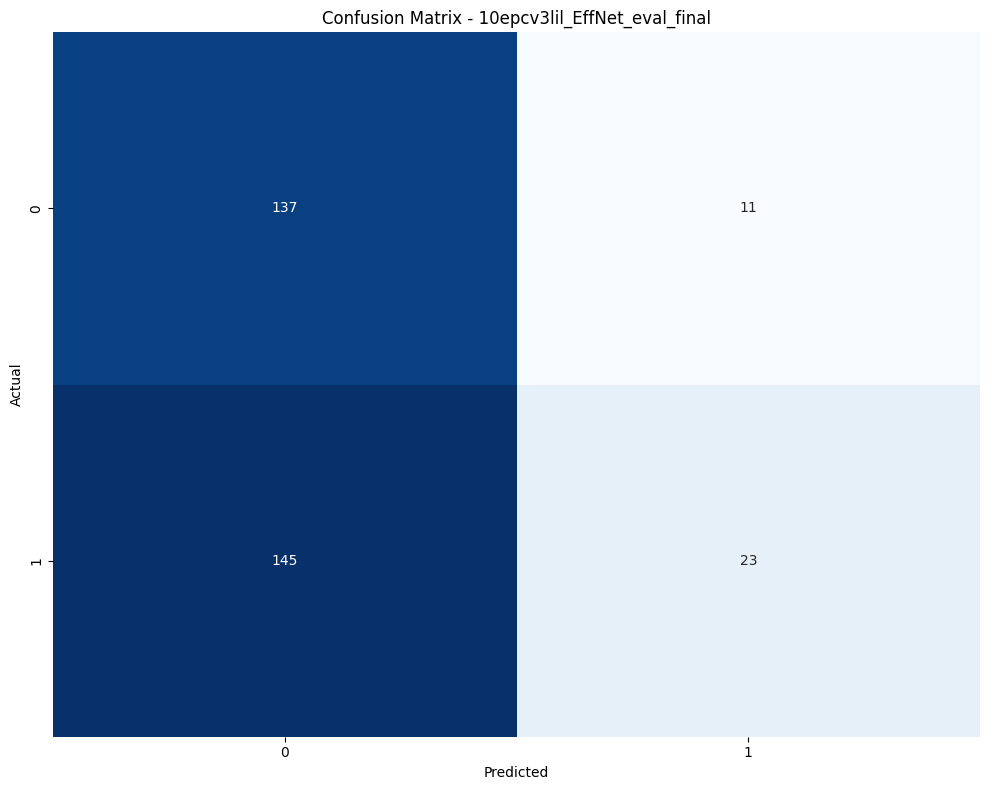


Metrics for 10epcv3lil_EffNet_eval_final:
Accuracy: 0.5063
Precision: 0.6765
Recall: 0.1369
F1 Score: 0.2277


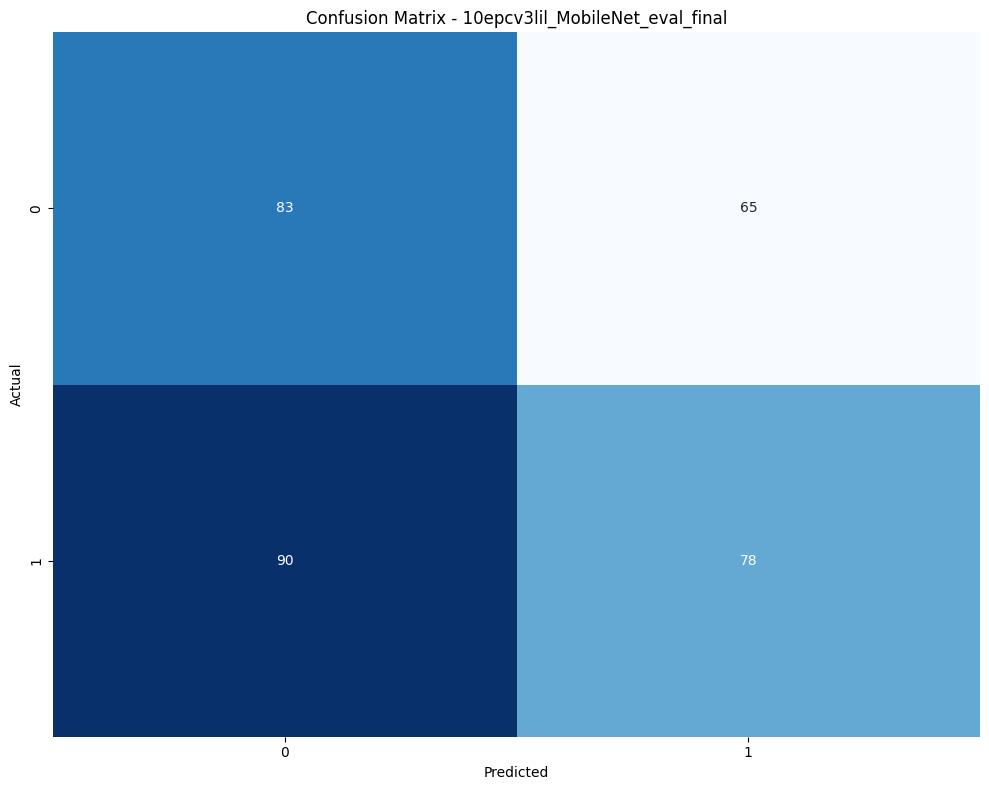


Metrics for 10epcv3lil_MobileNet_eval_final:
Accuracy: 0.5095
Precision: 0.5455
Recall: 0.4643
F1 Score: 0.5016


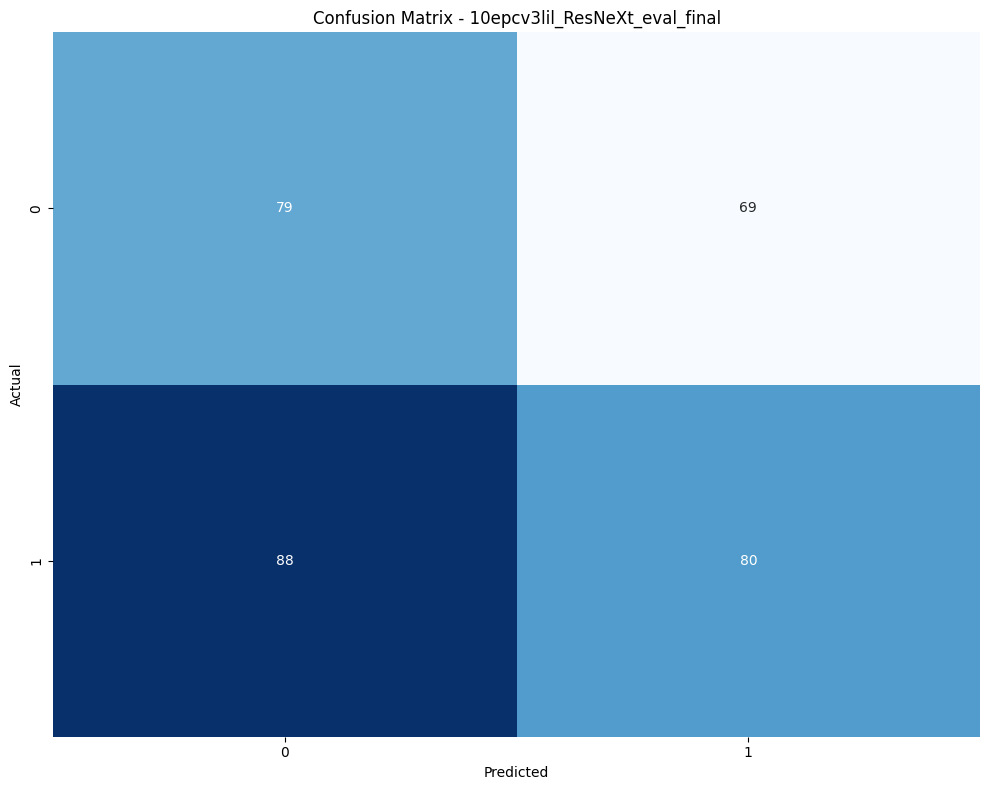


Metrics for 10epcv3lil_ResNeXt_eval_final:
Accuracy: 0.5032
Precision: 0.5369
Recall: 0.4762
F1 Score: 0.5047


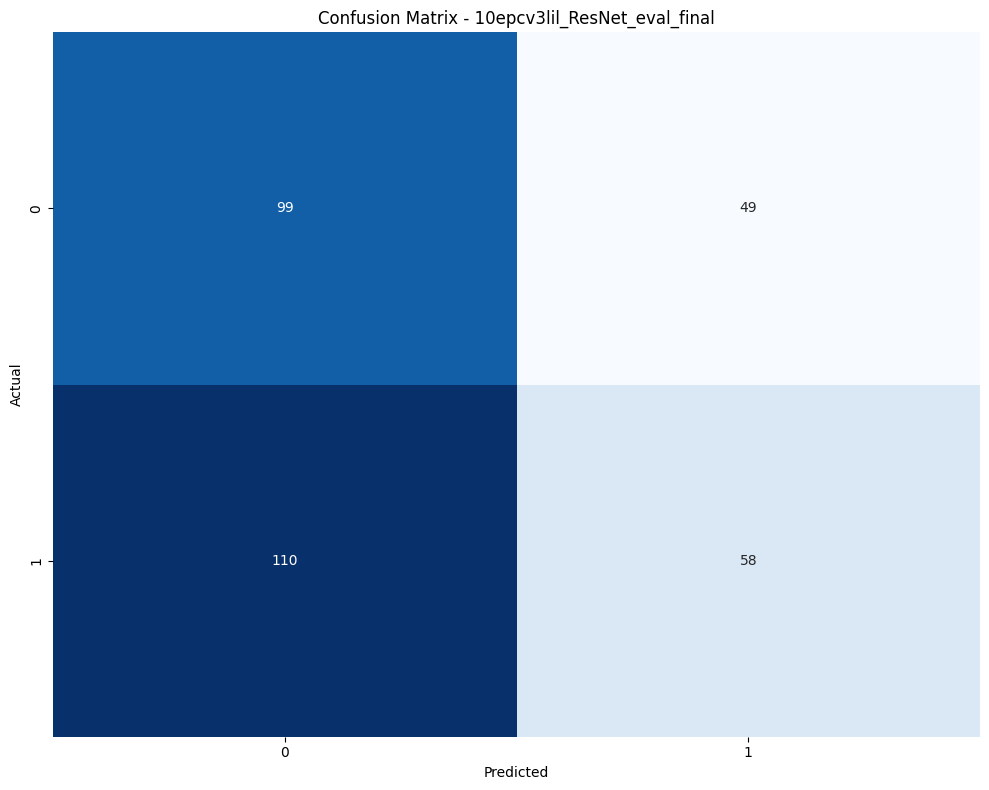


Metrics for 10epcv3lil_ResNet_eval_final:
Accuracy: 0.4968
Precision: 0.5421
Recall: 0.3452
F1 Score: 0.4218


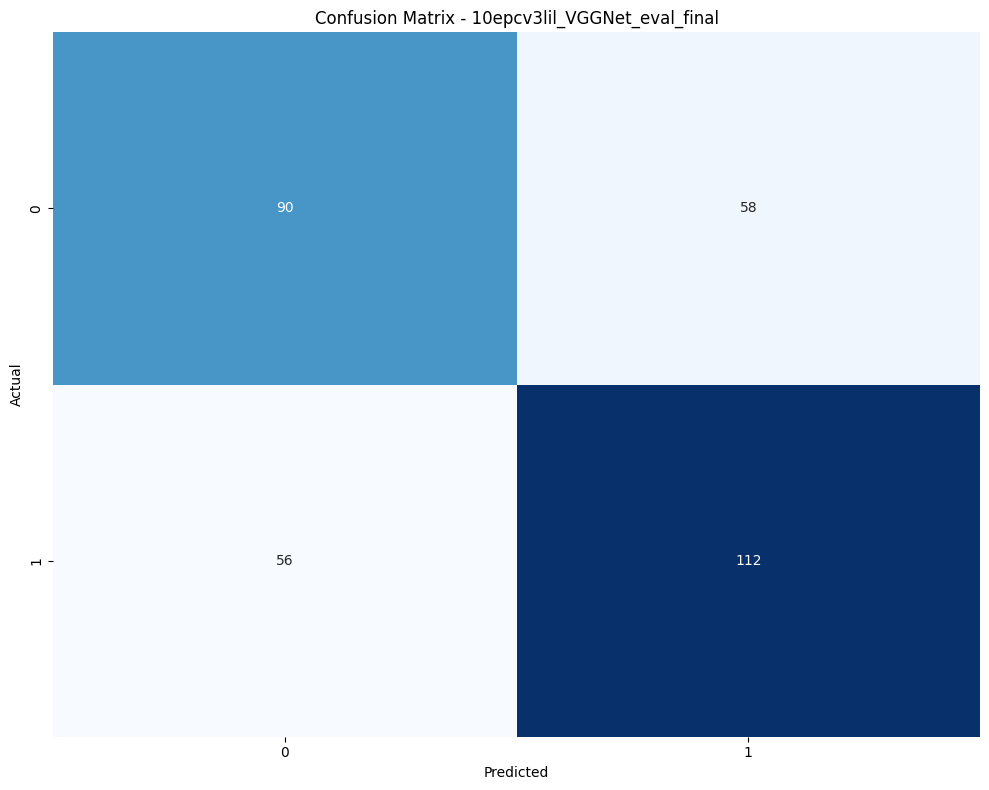


Metrics for 10epcv3lil_VGGNet_eval_final:
Accuracy: 0.6392
Precision: 0.6588
Recall: 0.6667
F1 Score: 0.6627
Confusion matrix plots have been saved for each model.


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('cms_lil.csv')

def plot_confusion_matrix(cm, name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Calculate metrics
    tn, fp, fn, tp = cm.values.ravel()
    total = tn + fp + fn + tp
    accuracy = (tn + tp) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # # Add metrics to plot
    # plt.text(0.5, -0.15, f'Accuracy: {accuracy:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
    # plt.text(0.5, -0.20, f'Precision: {precision:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
    # plt.text(0.5, -0.25, f'Recall: {recall:.4f}', ha='center', va='center', transform=plt.gca().transAxes)
    # plt.text(0.5, -0.30, f'F1 Score: {f1_score:.4f}', ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    # plt.savefig(f'confusion_matrix_{name}.png
    # ', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\nMetrics for {name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

# Group by name and create confusion matrix for each
for name, group in df.groupby('name'):
    cm = group.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
    # cm = cm.reindex(index=['0', '1'], columns=['0', '1'], fill_value=0)
    cm = cm.astype(int)
    plot_confusion_matrix(cm, name)

print("Confusion matrix plots have been saved for each model.")

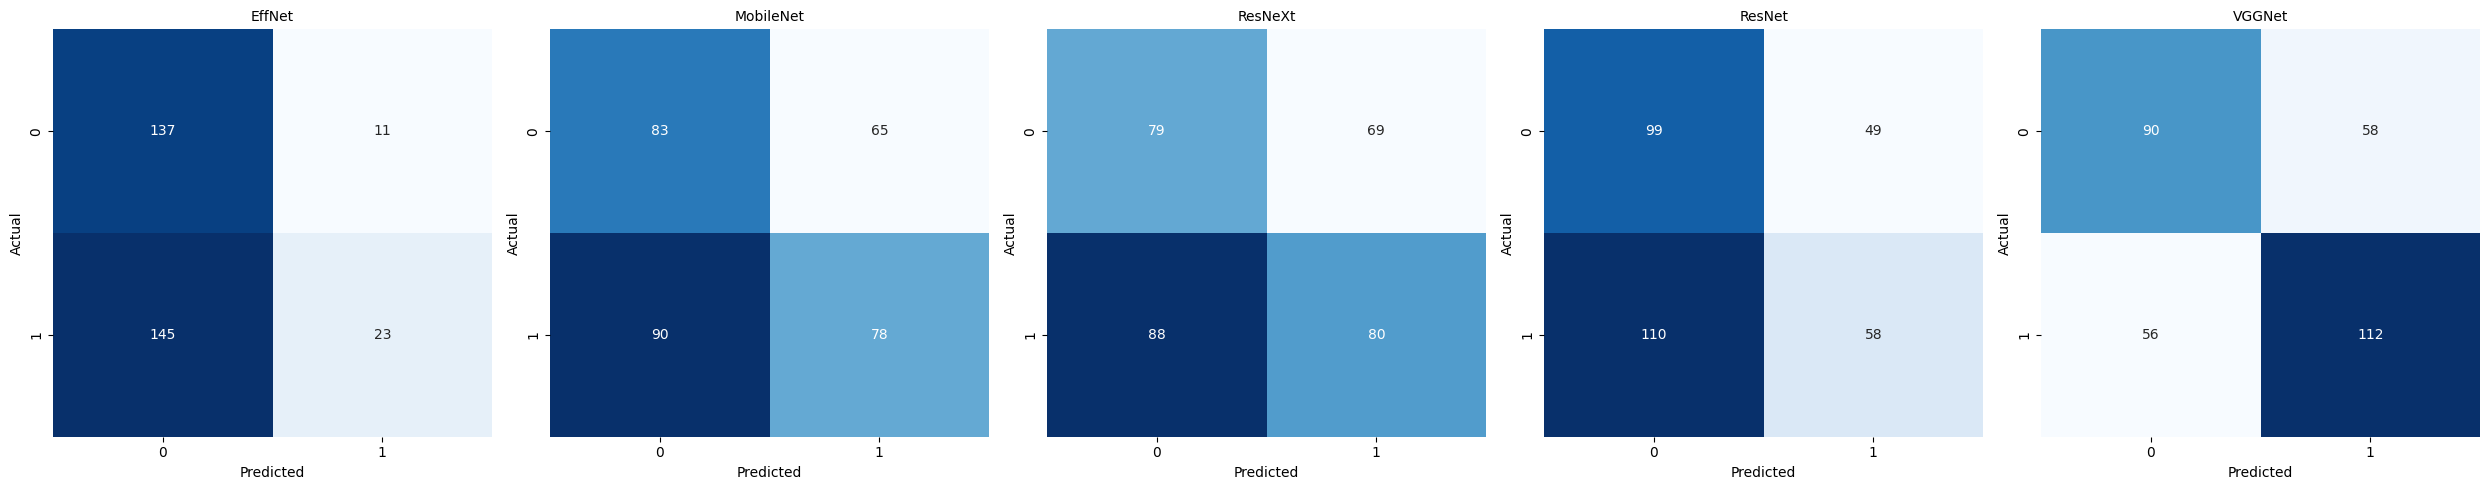


Metrics for all models:

EffNet:
Accuracy: 0.5063
Precision: 0.6765
Recall: 0.1369
F1 Score: 0.2277

MobileNet:
Accuracy: 0.5095
Precision: 0.5455
Recall: 0.4643
F1 Score: 0.5016

ResNeXt:
Accuracy: 0.5032
Precision: 0.5369
Recall: 0.4762
F1 Score: 0.5047

ResNet:
Accuracy: 0.4968
Precision: 0.5421
Recall: 0.3452
F1 Score: 0.4218

VGGNet:
Accuracy: 0.6392
Precision: 0.6588
Recall: 0.6667
F1 Score: 0.6627


In [52]:
def plot_confusion_matrix2(ax, cm, name):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name}', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

    # Calculate metrics
    tn, fp, fn, tp = cm.values.ravel()
    total = tn + fp + fn + tp
    accuracy = (tn + tp) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # # Add metrics to plot
    # ax.text(0.5, -0.25, f'Acc: {accuracy:.2f}\nPrec: {precision:.2f}\nRec: {recall:.2f}\nF1: {f1_score:.2f}', 
    #         ha='center', va='center', transform=ax.transAxes, fontsize=8)

    return accuracy, precision, recall, f1_score

# Create a single figure with subplots
fig, axes = plt.subplots(1, 5, figsize=(25, 5))


# Group by name and create confusion matrix for each
metrics = {}
for (name, group), ax in zip(df.groupby('name'), axes):
    cm = group.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
    cm = cm.astype(int)
    
    metrics[name] = plot_confusion_matrix2(ax, cm, name.split('_')[1])  # Use only the model name part

plt.tight_layout()
plt.savefig('all_confusion_matrices_lil.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Print metrics for all models
print("\nMetrics for all models:")
for name, (accuracy, precision, recall, f1_score) in metrics.items():
    print(f"\n{name.split('_')[1]}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

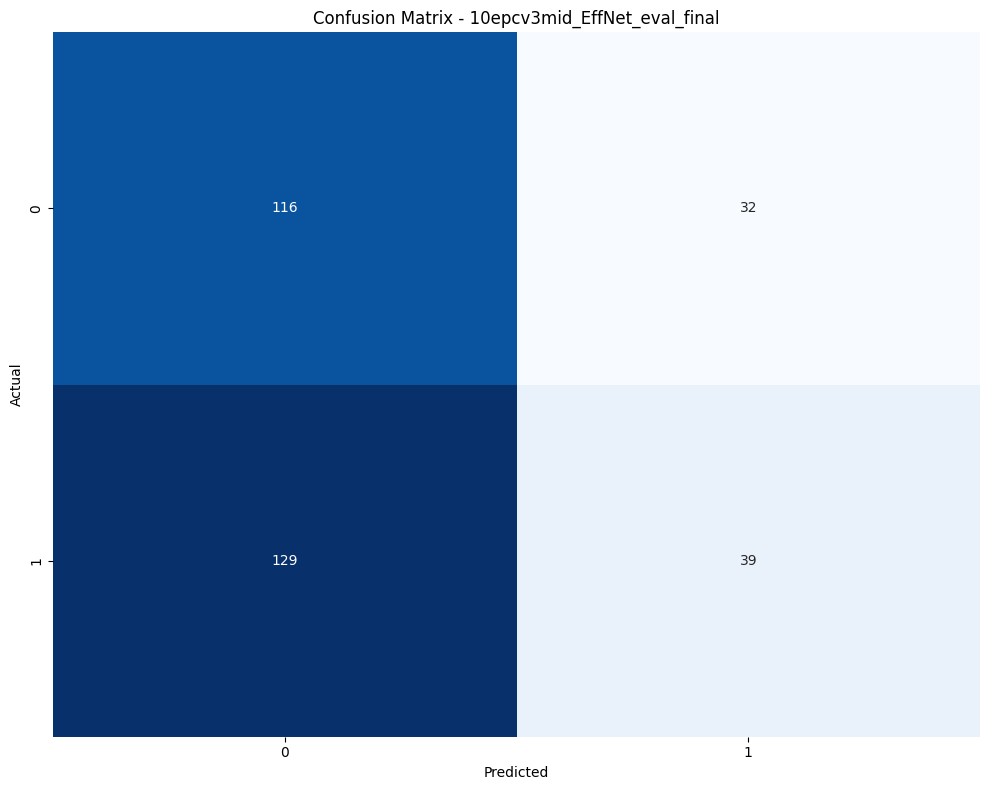


Metrics for 10epcv3mid_EffNet_eval_final:
Accuracy: 0.4905
Precision: 0.5493
Recall: 0.2321
F1 Score: 0.3264


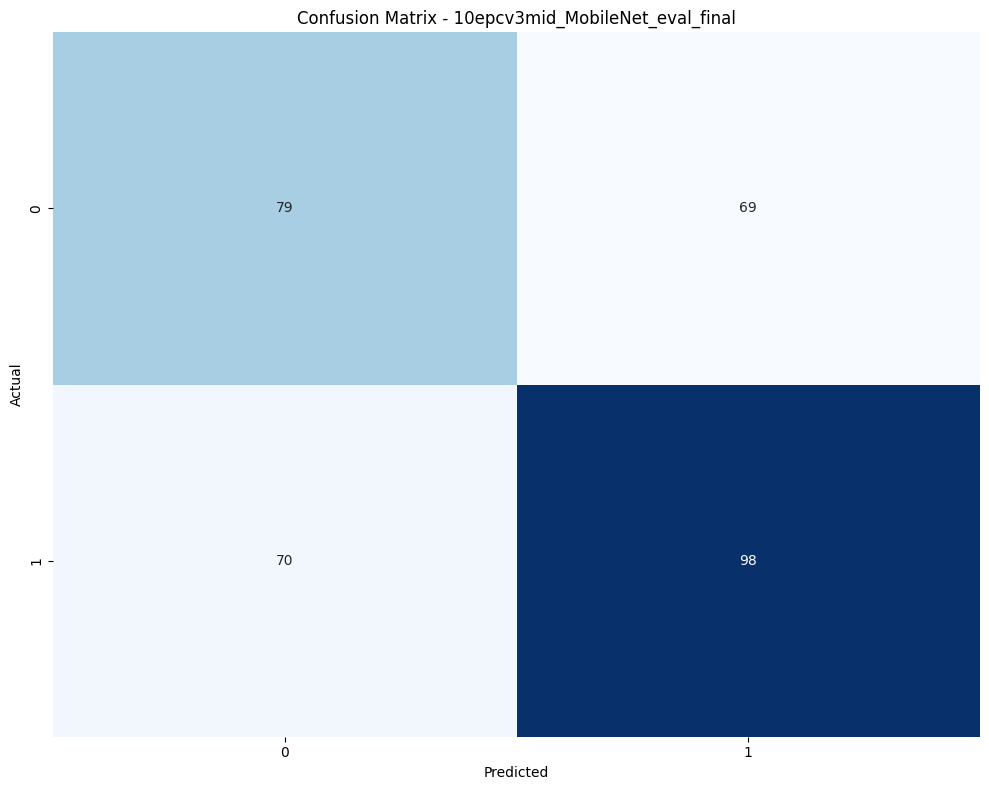


Metrics for 10epcv3mid_MobileNet_eval_final:
Accuracy: 0.5601
Precision: 0.5868
Recall: 0.5833
F1 Score: 0.5851


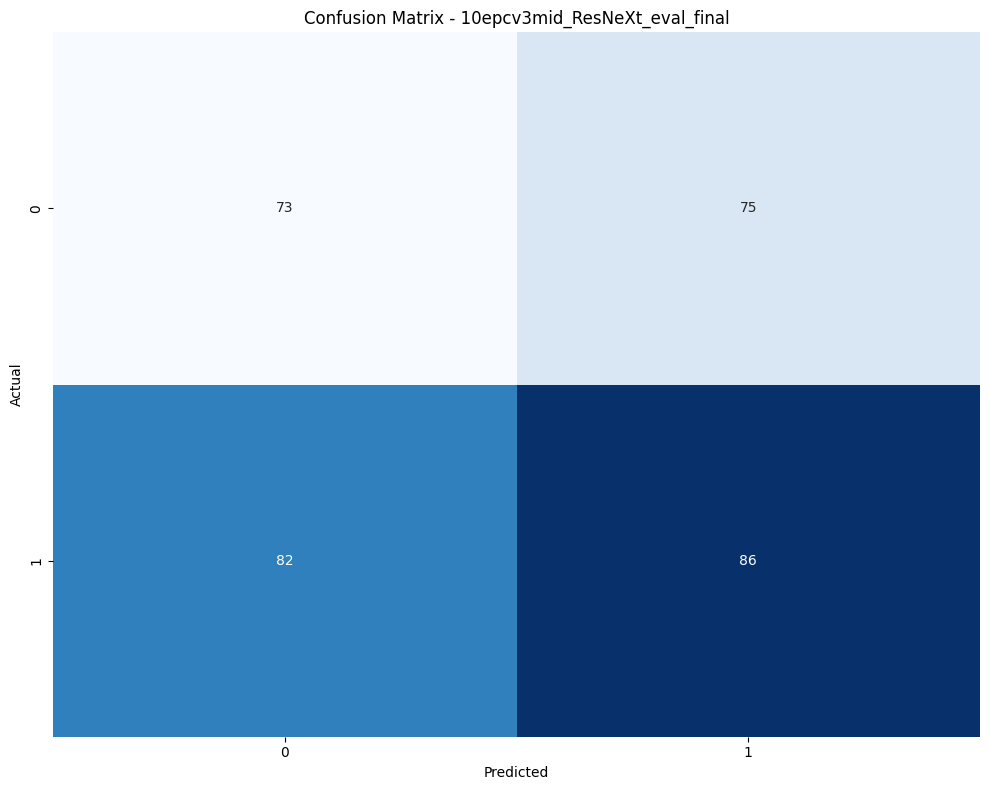


Metrics for 10epcv3mid_ResNeXt_eval_final:
Accuracy: 0.5032
Precision: 0.5342
Recall: 0.5119
F1 Score: 0.5228


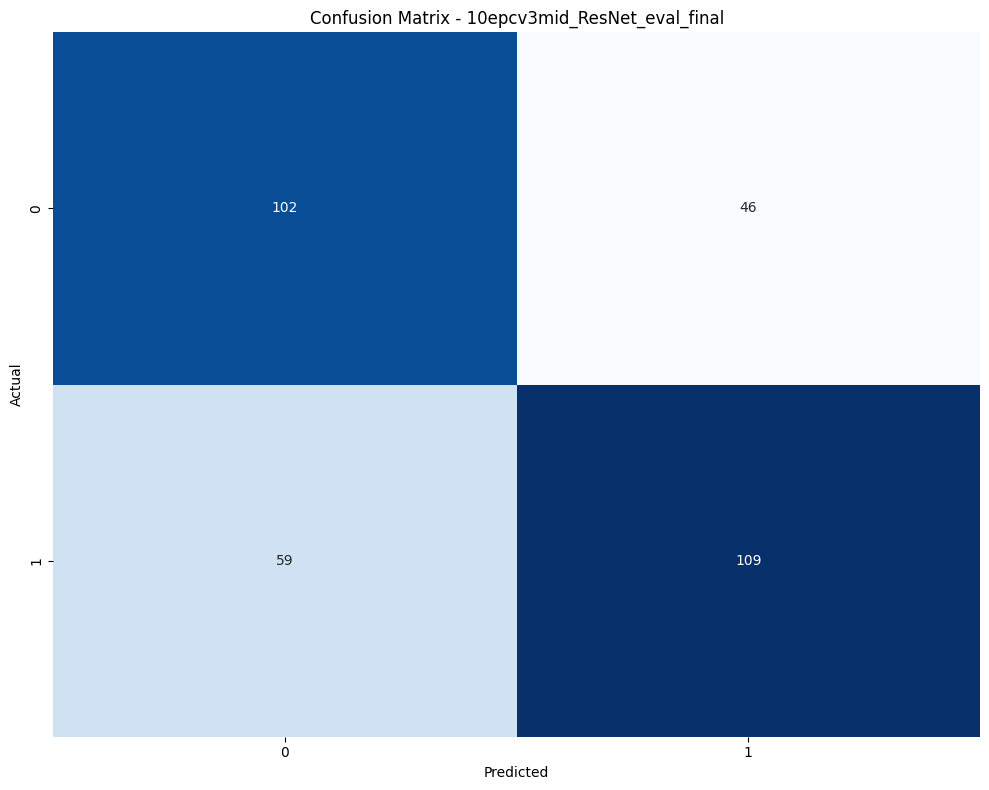


Metrics for 10epcv3mid_ResNet_eval_final:
Accuracy: 0.6677
Precision: 0.7032
Recall: 0.6488
F1 Score: 0.6749


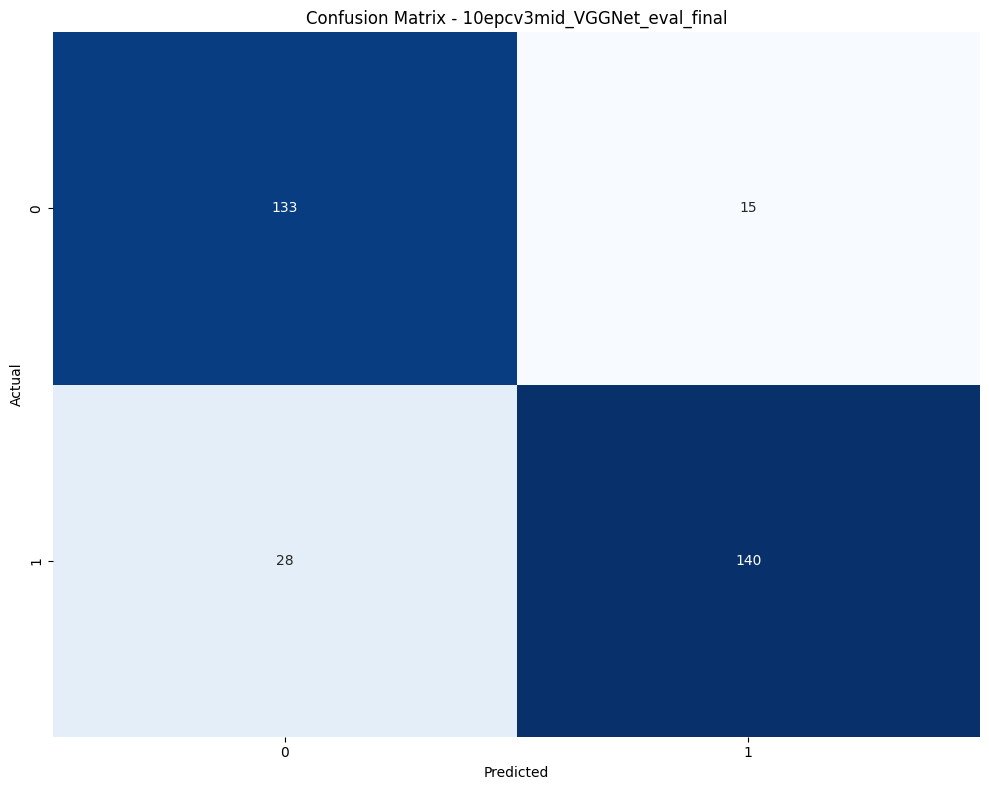


Metrics for 10epcv3mid_VGGNet_eval_final:
Accuracy: 0.8639
Precision: 0.9032
Recall: 0.8333
F1 Score: 0.8669
Confusion matrix plots have been saved for each model.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('cms_mid.csv')

# Group by name and create confusion matrix for each
for name, group in df.groupby('name'):
    cm = group.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
    # cm = cm.reindex(index=['0', '1'], columns=['0', '1'], fill_value=0)
    cm = cm.astype(int)
    plot_confusion_matrix(cm, name)

print("Confusion matrix plots have been saved for each model.")

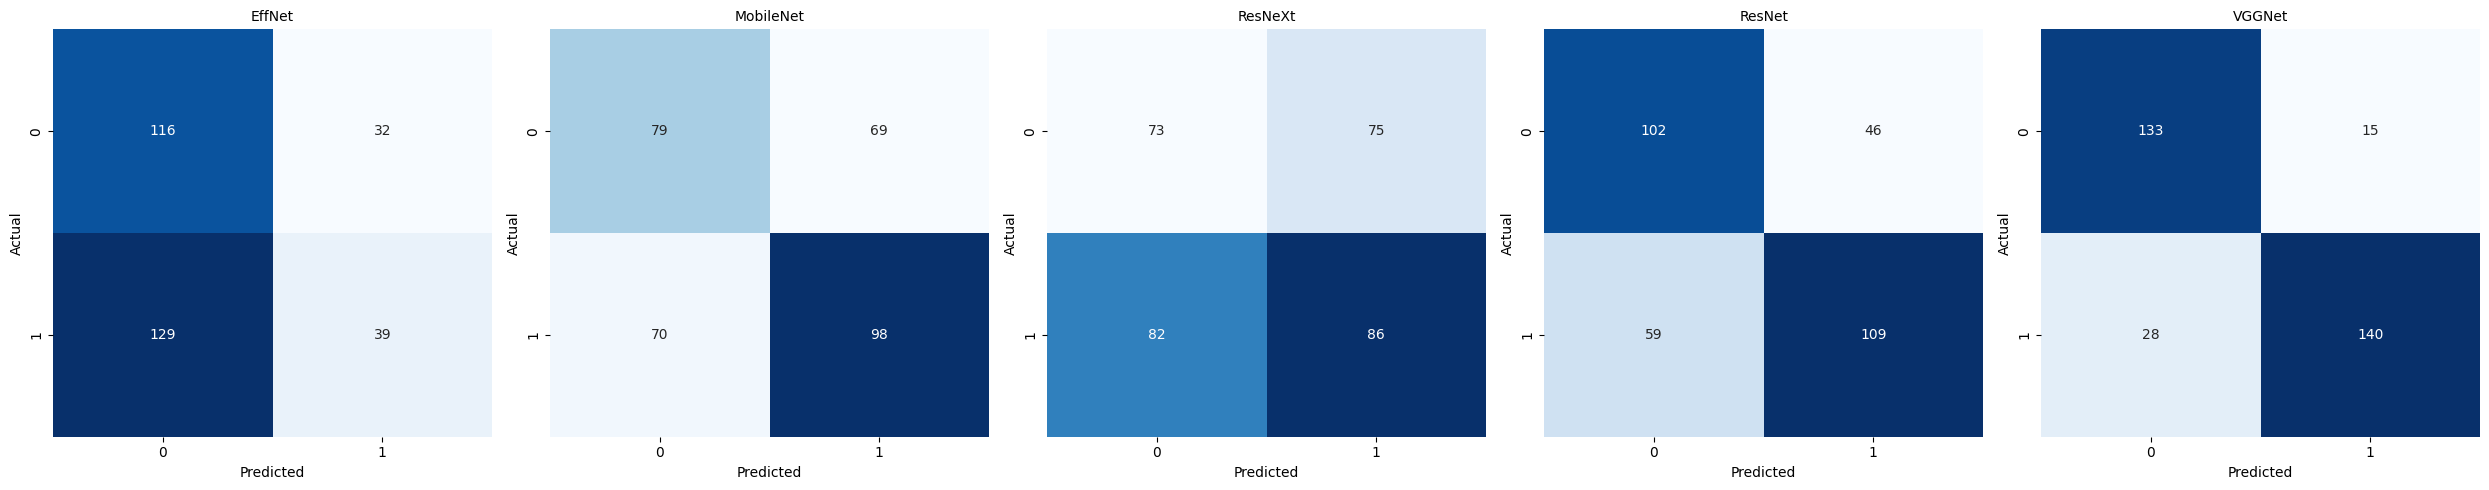


Metrics for all models:

EffNet:
Accuracy: 0.4905
Precision: 0.5493
Recall: 0.2321
F1 Score: 0.3264

MobileNet:
Accuracy: 0.5601
Precision: 0.5868
Recall: 0.5833
F1 Score: 0.5851

ResNeXt:
Accuracy: 0.5032
Precision: 0.5342
Recall: 0.5119
F1 Score: 0.5228

ResNet:
Accuracy: 0.6677
Precision: 0.7032
Recall: 0.6488
F1 Score: 0.6749

VGGNet:
Accuracy: 0.8639
Precision: 0.9032
Recall: 0.8333
F1 Score: 0.8669


In [54]:
# Create a single figure with subplots
fig, axes = plt.subplots(1, 5, figsize=(25, 5))


# Group by name and create confusion matrix for each
metrics = {}
for (name, group), ax in zip(df.groupby('name'), axes):
    cm = group.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
    cm = cm.astype(int)
    
    metrics[name] = plot_confusion_matrix2(ax, cm, name.split('_')[1])  # Use only the model name part

plt.tight_layout()
plt.savefig('all_confusion_matrices_mid.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Print metrics for all models
print("\nMetrics for all models:")
for name, (accuracy, precision, recall, f1_score) in metrics.items():
    print(f"\n{name.split('_')[1]}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")